In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.style import (  # noqa: E402
    save_figure,
    new_figure,
    WIDTHS,
    )
from sse_detection import lib as sselib  # noqa: E402

OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "outputs"
FIG_DIR = PROJECT_ROOT / "sse_detection" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

def save_plot(
    plot,
    stem,
    width: WIDTHS = "double",
    width_in=None,
    height_in=3.5,
    
):
    if not SAVE_FIGURES:
        return
    save_figure(
        plot,
        FIG_DIR / stem,
        width=width,
        width_in=width_in,
        height_in=height_in,
        save_pdf=True,
        save_png=True,
    )

## Load Outputs

`load_sse_outputs` returns a container with the static parquet tables: `node_stats`, `edge_table`, `candidate_review`, `meta_summary`.

In [2]:
outs = sselib.load_sse_outputs(OUTPUT_DIR)
node_stats = outs.node_stats
min_size = node_stats[node_stats["sse_candidate"]]["cluster_size"].min()
edge_table = outs.edge_table
candidate_review = outs.candidate_review
meta_summary = outs.meta_summary
candidates = outs.candidates

print(f"node_stats: {node_stats.shape[0]:,} rows x {node_stats.shape[1]:,} columns")
print(f"edge_table: {edge_table.shape[0]:,} rows")
print(f"candidate nodes: {len(candidates):,}")
print(f"background nodes: {(node_stats["cluster_size"].ge(min_size)).sum() - len(candidates):,}")

node_stats: 99,006 rows x 142 columns
edge_table: 41,747 rows
candidate nodes: 10,672
background nodes: 19,034


## Output Summary Table

In [3]:
summary = pd.DataFrame(
    [
        ("node-clusters", len(node_stats)),
        ("directed edges", len(edge_table)),
        ("meta-clusters", meta_summary["meta_cluster_id"].nunique()),
        ("SSE-like candidate nodes", int(node_stats["sse_candidate"].sum())),
        ("candidate share of nodes", float(node_stats["sse_candidate"].mean())),
        (f"background nodes (>= {min_size})", int(node_stats["cluster_size"].ge(min_size).sum() - node_stats["sse_candidate"].sum())),
        (f"background share of nodes (>= {min_size})", float(node_stats["cluster_size"].ge(min_size).mean() - node_stats["sse_candidate"].mean())),
        ("unique candidate categories", candidates["sse_category"].nunique()),
    ],
    columns=["quantity", "value"],
)

summary["display_value"] = summary["value"].map(
    lambda x: (
        f"{x:,.1%}"
        if isinstance(x, float) and x < 1
        else f"{x:,.0f}"
        if pd.notna(x)
        else "NA"
    )
)

display(summary[["quantity", "display_value"]])

,quantity,display_value
0,node-clusters,"99,006"
1,directed edges,"41,747"
2,meta-clusters,"57,354"
3,SSE-like candidate nodes,"10,672"
4,candidate share of nodes,10.8%
5,background nodes (>= 3),"19,034"
6,background share of nodes (>= 3),19.2%
7,unique candidate categories,21


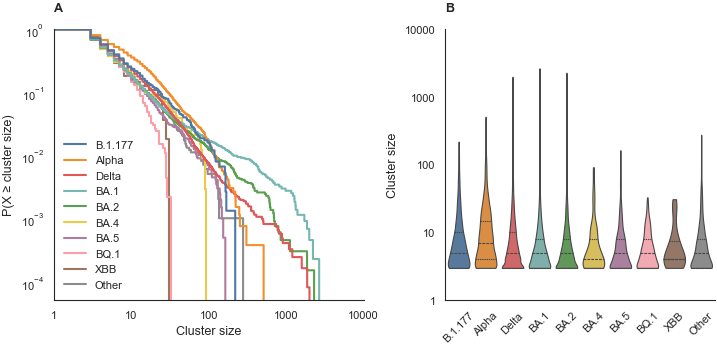

In [4]:
fig = sselib.plot_cluster_size_distribution(
    node_stats, min_size=min_size
)
display(fig)
save_plot(fig, "fig01_cluster_size",  height_in=3.5)

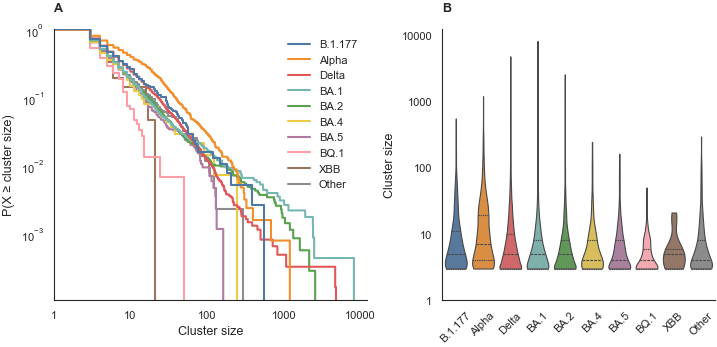

In [5]:
fig = sselib.plot_cluster_size_distribution(
    meta_summary, size_col="n_sequences", min_size=min_size
)
display(fig)
save_plot(fig, "fig02_meta_cluster_size", height_in=3.5)

In [6]:
sse_roles = node_stats["sse_role"].dropna().unique()

role_summary = (
    node_stats
    .groupby("meta_cluster_id")["sse_role"]
    .nunique()
    .reset_index(name="n_roles_represented")
)

max_roles = role_summary["n_roles_represented"].max()

meta_ids = role_summary[
    role_summary["n_roles_represented"] == max_roles
    ]["meta_cluster_id"].tolist()

meta_ids

['AM00001',
 'AM00002',
 'AM00007',
 'AM00009',
 'AM00011',
 'AM00012',
 'AM00062',
 'AM00142',
 'AM00206']

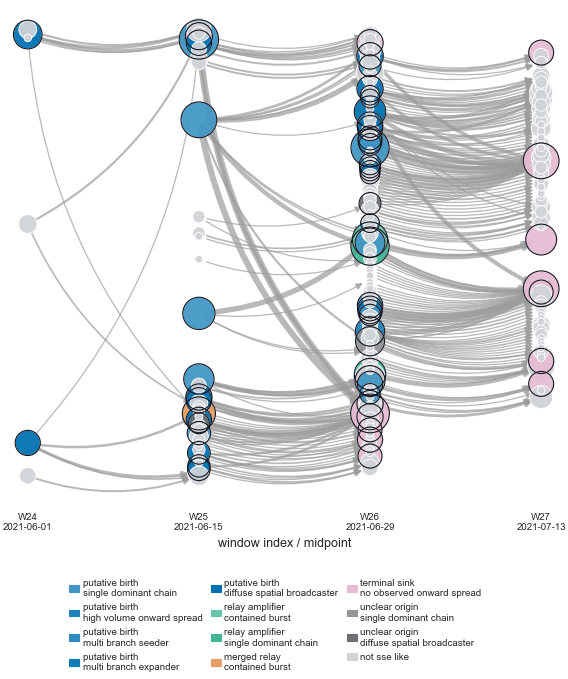

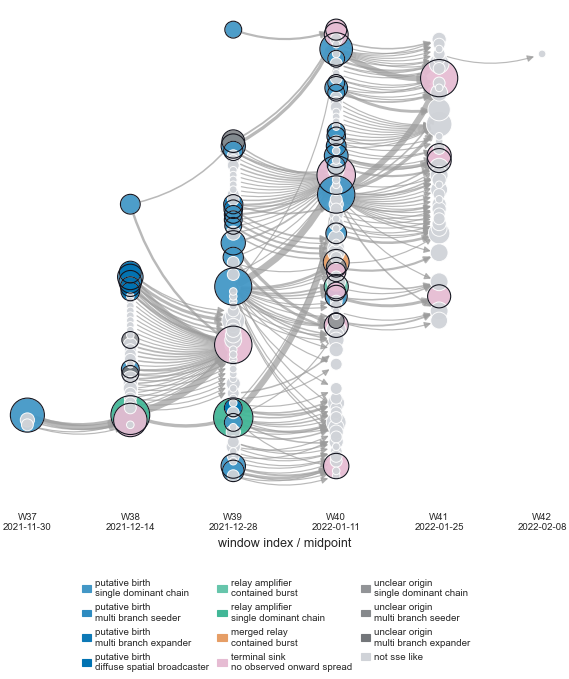

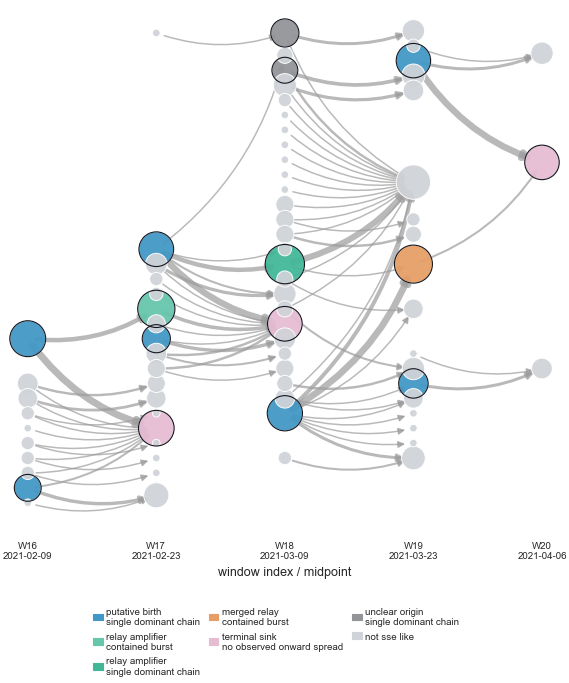

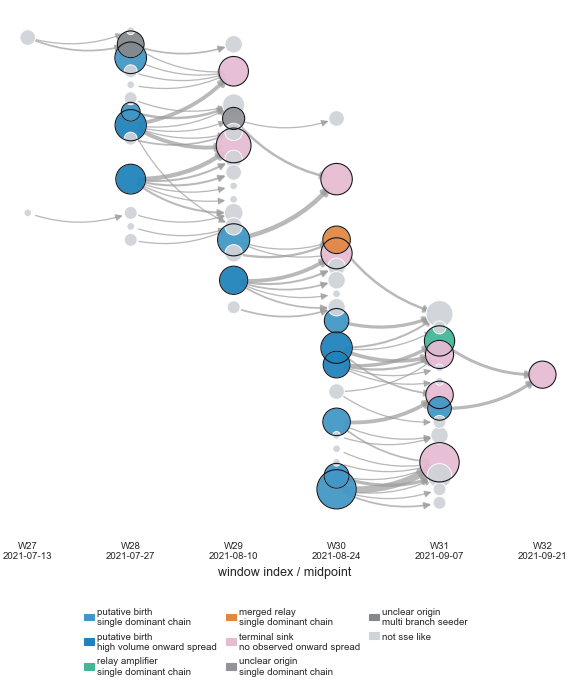

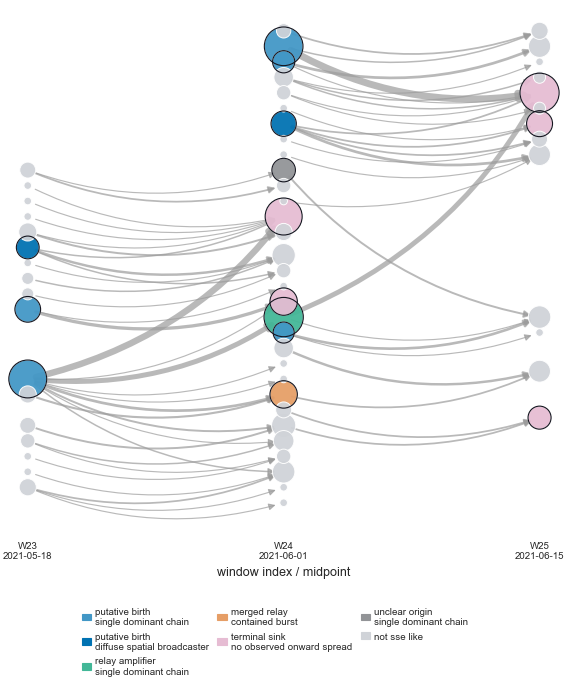

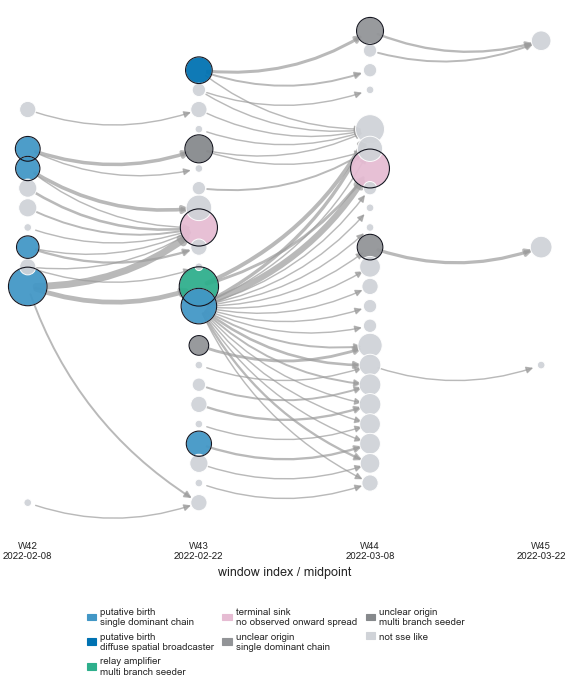

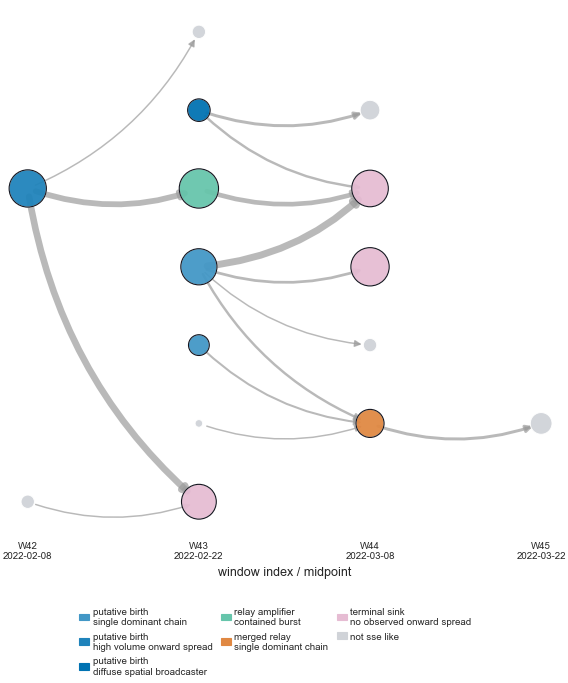

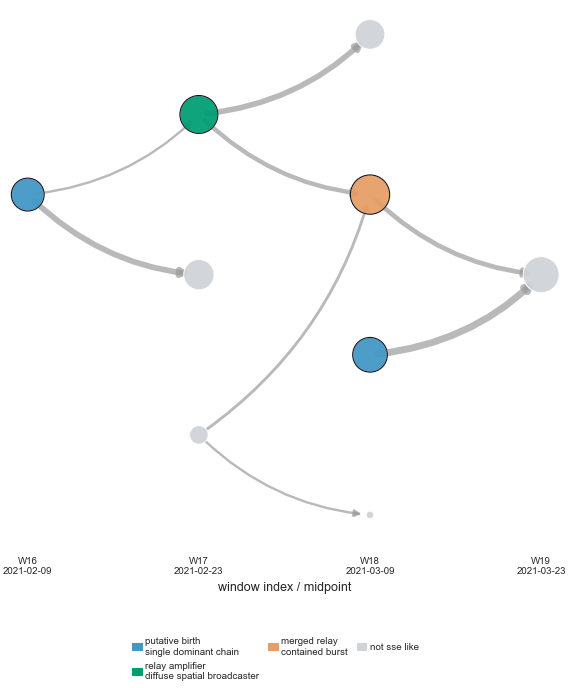

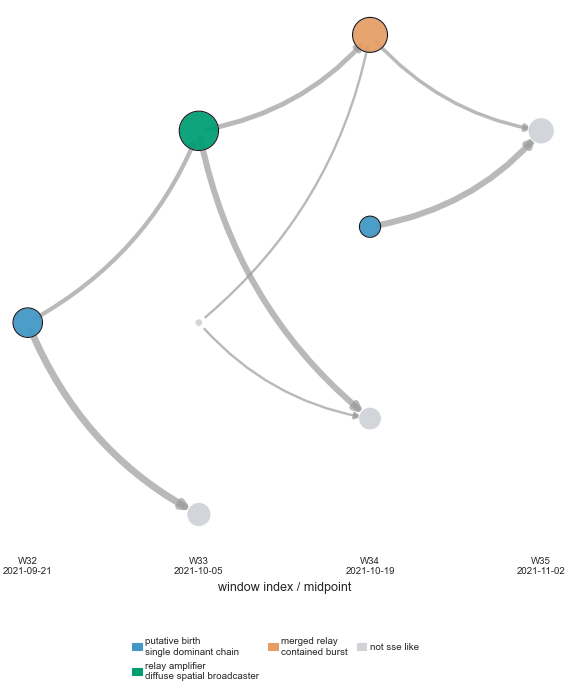

In [7]:
for meta_id in meta_ids[:10]:
    fig = sselib.plot_meta_cluster_subgraph(
        node_stats=node_stats,
        edge_table=edge_table,
        meta_cluster_id=meta_id,
        color_by="sse_category",
        annotate_top_n=0,
        rankdir="LR",
        height_in=8,
    )
    display(fig)
    save_plot(fig, f"fig03_subgraph_{meta_id}_exemplar", height_in=8.0)

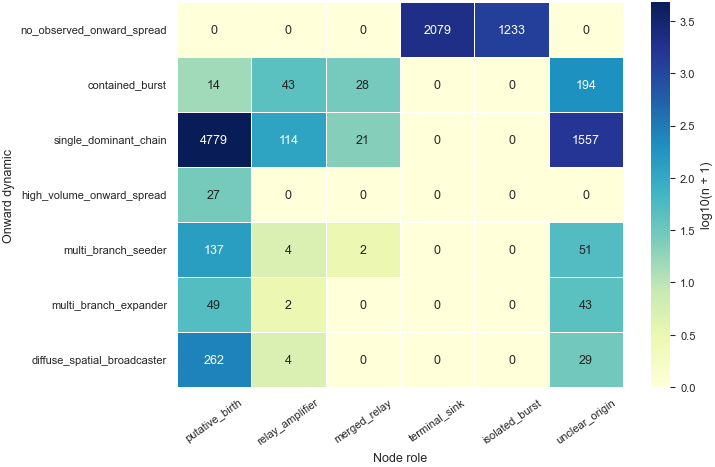

In [8]:
fig = sselib.plot_role_dynamic_heatmap(candidates)
display(fig)
save_plot(fig, "fig04_role_onward_heatmap", height_in=5)

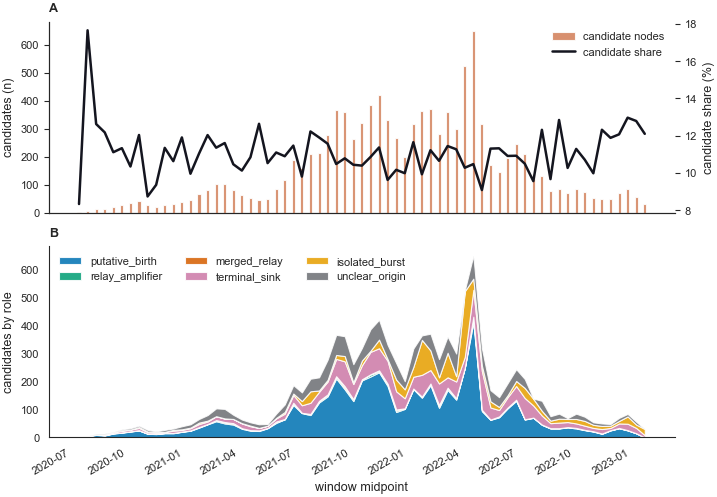

In [9]:
fig = sselib.plot_candidate_rate_over_time(node_stats)
display(fig)
save_plot(fig, "fig05_candidate_rate_over_time", height_in=5)

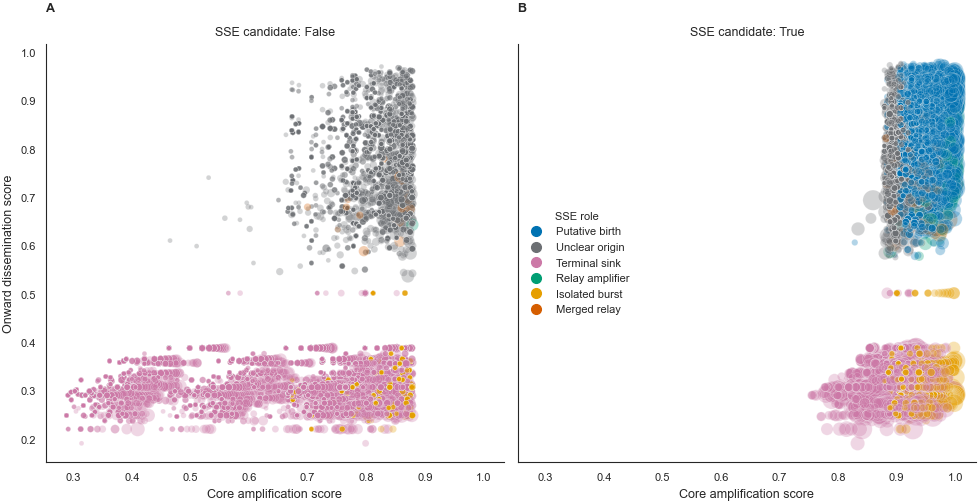

In [10]:
fig = sselib.plot_core_metric_space(node_stats, min_size=min_size)
display(fig)
save_plot(fig, "fig06_metric_space_scatter", height_in=3.5)

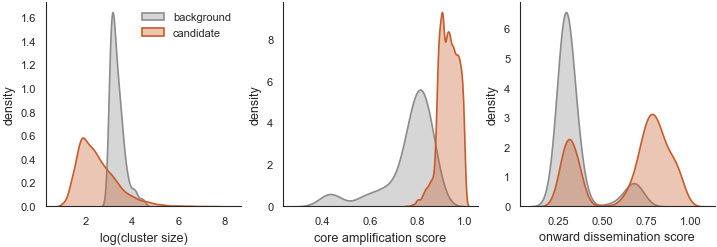

In [ ]:
fig = sselib.plot_composite_distributions(node_stats, min_size=min_size)
display(fig)
save_plot(fig, "fig07_composite_score_distributions", height_in=2.5)

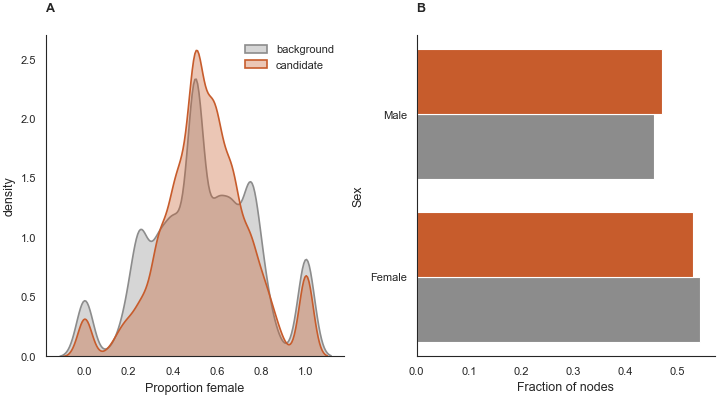

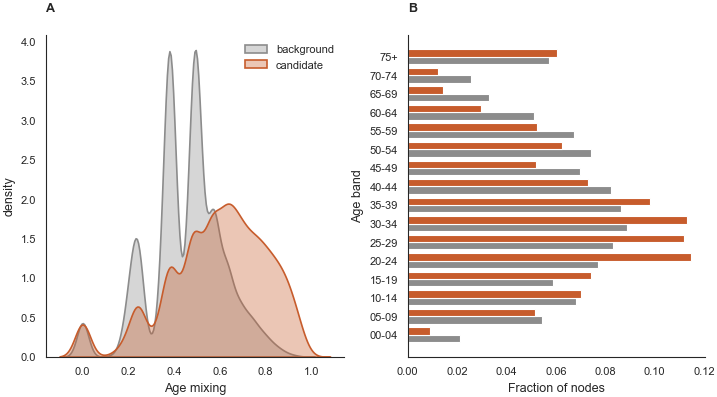

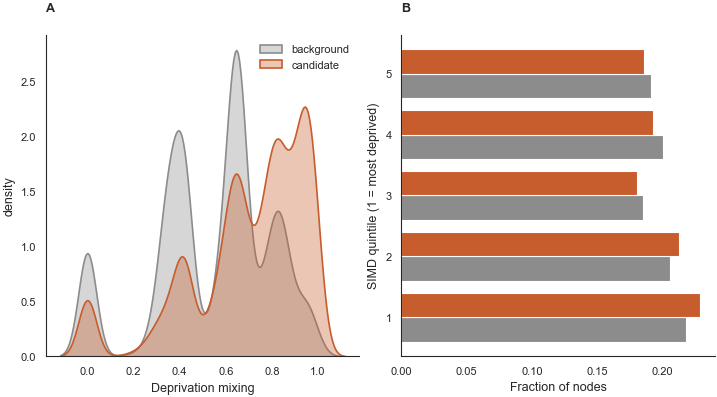

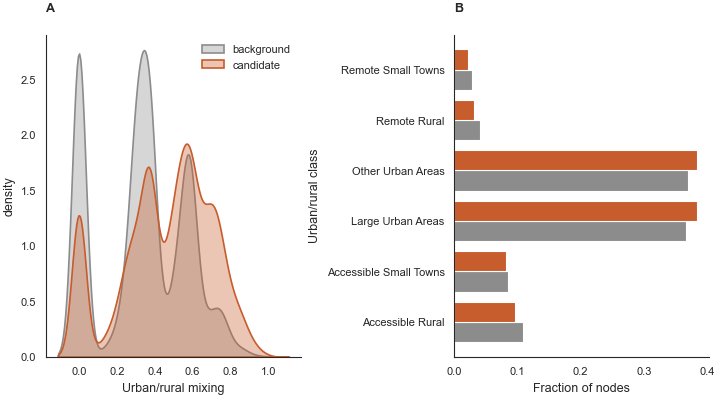

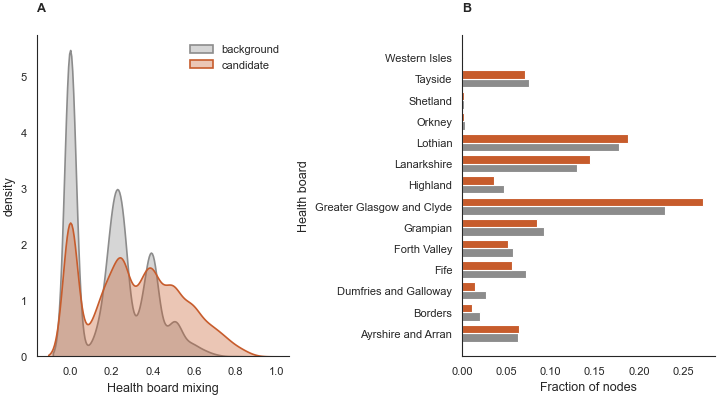

In [ ]:
socio_demo_cols = [
    ("sex_counts", "fraction_female", ("Fraction female", "Sex")),
    ("age_band_counts", "age_entropy_obs",("Age mixing",  "Age band")),
    ("simd_quintile_counts","simd_entropy_obs", ("Deprivation mixing", "SIMD quintile (1 = most deprived)")),
    ("urban_rural_class_counts",  "urban_rural_entropy_obs", ("Urban/rural mixing", "Urban/rural class")),
    ("health_board_counts",  "health_board_entropy_obs", ("Health board mixing", "Health board")),
]

socio_demo_records = {}

for col, score, label in socio_demo_cols:

    fig, df = sselib.plot_socio_demo_breakdown(
        node_stats, min_size=min_size,
        col=col,
        score=score,
        xlabels=label,
    )
    display(fig)
    save_plot(fig, f"fig08_{col}_{score}_breakdown", height_in=4)
    socio_demo_records[col] = df

The age-band composition of SSE candidates differs significantly from the background distribution, χ²(15) = 7270.14, p < 0.001. Candidate nodes are over-represented among young adults, particularly ages 20–24, 25–29, and 30–34. The largest absolute difference occurs for ages 20–24, which make up 11.5% of candidate counts compared with 7.7% of background counts. In contrast, candidate nodes are under-represented in older age bands, especially 60–64, 65–69, and 70–74. Although almost all age bands are statistically significant after correction, interpretation should focus on effect size because the total count is large.

In [ ]:
sex = sselib.test_category_distribution(pd.DataFrame(socio_demo_records["sex_counts"]))

print(
    f"Chi-square test: "
    f"χ²({sex['dof']}) = {sex['chi2']:.2f}, "
    f"p = {sex['p_value']:.3g}"
)

display(sex["per_category_tests"])

age_bands = sselib.test_category_distribution(pd.DataFrame(socio_demo_records["age_band_counts"]))

print(
    f"Chi-square test: "
    f"χ²({age_bands['dof']}) = {age_bands['chi2']:.2f}, "
    f"p = {age_bands['p_value']:.3g}"
)

display(age_bands["per_category_tests"])

simd_quintiles = sselib.test_category_distribution(pd.DataFrame(socio_demo_records["simd_quintile_counts"]))

print(
    f"Chi-square test: "
    f"χ²({simd_quintiles['dof']}) = {simd_quintiles['chi2']:.2f}, "
    f"p = {simd_quintiles['p_value']:.3g}"
)

display(simd_quintiles["per_category_tests"])

Chi-square test: χ²(1) = 77.36, p = 1.43e-18


,q,candidate_n,background_n,candidate_frac,background_frac,diff_candidate_minus_background,odds_ratio,p_value,p_adj_bh
0,Female,123837,91389,0.530331,0.544371,-0.01404,0.945085,1.401833e-18,1.401833e-18
1,Male,109672,76491,0.469669,0.455629,0.01404,1.058105,1.401833e-18,1.401833e-18


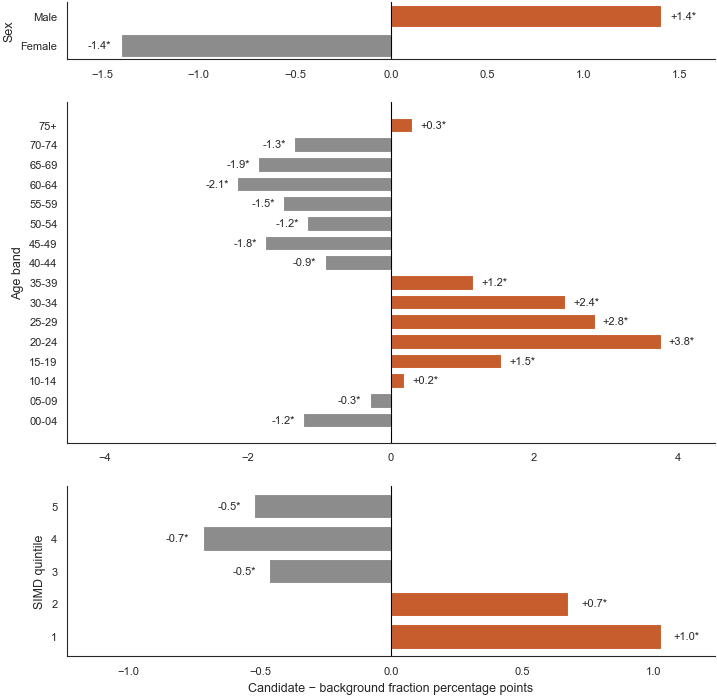

In [27]:
fig, axes = new_figure(
    width="double",
    height_in=7,
    context="paper",
    font_scale=1,
    nrows=3,
    gridspec_kw={"height_ratios": [0.1, 0.6, 0.3], "hspace": 0.1},
    layout="constrained",
)

_ = sselib.plot_socio_demo_candidate_background_diff(
    sex["per_category_tests"],
    ylabel = "Sex",
    ax=axes[0],
    xlabel=""
)
_ = sselib.plot_socio_demo_candidate_background_diff(
    age_bands["per_category_tests"],
    ylabel = "Age band",
    ax=axes[1],
    xlabel=""
)
_ = sselib.plot_socio_demo_candidate_background_diff(
    simd_quintiles["per_category_tests"],
    ylabel = "SIMD quintile",
    ax=axes[2],
)

display(fig)

save_plot(fig, "fig09_socio_demo_candidate_background_diff", height_in=6)

In [ ]:
urban_rural = sselib.test_category_distribution(pd.DataFrame(socio_demo_records["urban_rural_class_counts"]))

print(
    f"Chi-square test: "
    f"χ²({urban_rural['dof']}) = {urban_rural['chi2']:.2f}, "
    f"p = {urban_rural['p_value']:.3g}"
)

display(urban_rural["per_category_tests"])

health_boards = sselib.test_category_distribution(pd.DataFrame(socio_demo_records["health_board_counts"]))

print(
    f"Chi-square test: "
    f"χ²({health_boards['dof']}) = {health_boards['chi2']:.2f}, "
    f"p = {health_boards['p_value']:.3g}"
)
display(health_boards["per_category_tests"])

Chi-square test: χ²(5) = 634.91, p = 5.77e-135


,q,candidate_n,background_n,candidate_frac,background_frac,diff_candidate_minus_background,odds_ratio,p_value,p_adj_bh
4,Remote Rural,7343,6783,0.031791,0.040412,-0.008621,0.779678,2.081229e-47,1.248737e-46
5,Remote Small Towns,5196,4844,0.022496,0.028859,-0.006364,0.774419,2.186641e-36,6.559922e-36
0,Accessible Rural,22385,18205,0.096914,0.108461,-0.011547,0.882115,1.531497e-32,3.062993e-32
2,Large Urban Areas,88601,61488,0.383592,0.366331,0.017261,1.076440,1.087139e-28,1.630709e-28
3,Other Urban Areas,88635,62119,0.383740,0.370091,0.013649,1.059844,1.666229e-18,1.999475e-18
1,Accessible Small Towns,18817,14409,0.081467,0.085846,-0.004379,0.944471,8.104192e-07,8.104192e-07


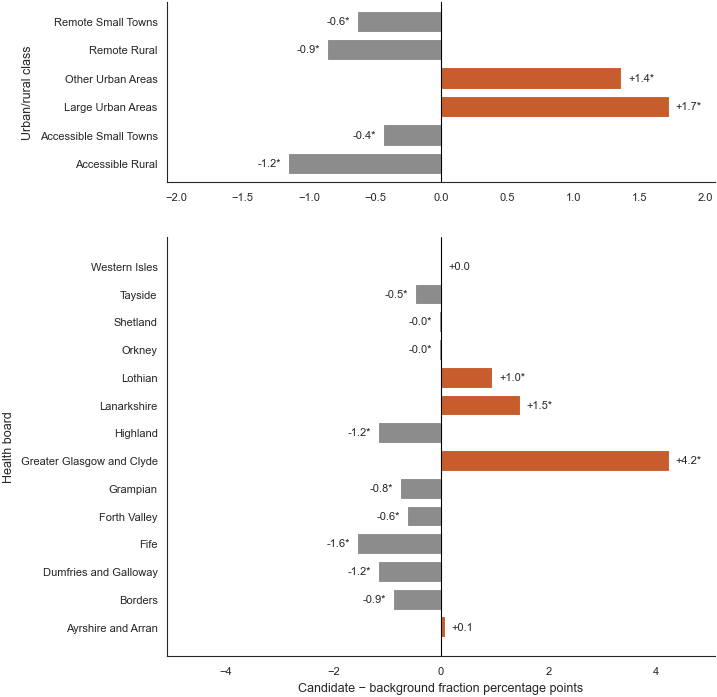

In [29]:
fig, axes = new_figure(
    width="double",
    height_in=7,
    context="paper",
    font_scale=1,
    nrows=2,
    gridspec_kw={"height_ratios": [0.3, 0.7], "hspace": 0.1},
    layout="constrained",
)
_ = sselib.plot_socio_demo_candidate_background_diff(
    urban_rural["per_category_tests"],
    ylabel = "Urban/rural class",
    ax=axes[0],
    xlabel=""
)
_ = sselib.plot_socio_demo_candidate_background_diff(
    health_boards["per_category_tests"],
    ylabel = "Health board",
    ax=axes[1],
)
display(fig)